# Notebook 5: Multiple Grubbs-Beck Test (MGBT) — Detecting Low Outliers

## Background: Potentially Influential Low Flows (PILFs)

In Flood Frequency Analysis, outliers at the **low end** of the record are as problematic as high outliers — but for a different reason. Very low annual maxima (near-drought years where the "flood" was trivially small) can:

1. **Pull the fitted distribution downward**, causing the model to underestimate flood risk at moderate and large return periods.
2. **Inflate the skewness estimate** in LP3 fitting — the sample skewness coefficient is notoriously sensitive to extreme values, and very small flows pull it as strongly as very large ones.
3. **Violate population homogeneity** — a near-zero annual maximum in a drought year may represent a fundamentally different hydrological state to a typical flood year.

**ARR 2019** recommends the **Multiple Grubbs-Beck Test (MGBT)** as a standard preprocessing step before LP3 and GEV fitting. Low outliers detected by MGBT are treated as **left-censored data** — meaning we know the flow was below a threshold, but we do not use its exact value in fitting. This is statistically more correct than deleting the observations entirely.

## The Grubbs-Beck Test Statistic

The test operates on log-transformed flows, consistent with the LP3 assumption that $\ln(Q)$ is approximately normally distributed. For each candidate low outlier, the test statistic is:

$$GB = \frac{\bar{Y} - Y_{(1)}}{S_Y}$$

where $\bar{Y}$ and $S_Y$ are the mean and standard deviation of log-flows, and $Y_{(1)}$ is the candidate (lowest) log-flow. This statistic is compared against a critical value at a chosen significance level. If $GB$ exceeds the critical value, the lowest value is declared an outlier, removed from the working dataset, and the test **iterates** on the remaining data — hence "Multiple" Grubbs-Beck.

The output is a **threshold flow value**: any annual maximum below this threshold is classified as a PILF and treated as left-censored in subsequent distribution fitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from flood_ffa.data.bom import load_ams, get_flow_series
from flood_ffa.preprocessing.mgbt import detect_low_outliers
import probscale

## 1. Load AMS Data

We load the same 55-year gauge record (1970–2024) used throughout this package.

In [2]:
df = load_ams("../data/AMS.csv")
flows = get_flow_series(df)
print(f"Loaded {len(flows)} observations.")

Loaded 55 observations.


## 2. Apply MGBT to the Gauge Record

The `detect_low_outliers()` function applies the iterative Grubbs-Beck test at the ARR-recommended significance level. The result object contains:

| Attribute | Meaning |
|---|---|
| `klow` | Number of low outliers detected |
| `low_outlier_threshold` | Flow threshold (m³/s) — values below this are PILFs |
| `cleaned_flows` | AMS with PILFs removed (for use in standard fitting) |
| `outlier_indices` | Year indices of detected PILFs |

**A result of `klow = 0` is a positive finding.** It confirms that all 55 annual maxima are drawn from a statistically consistent log-normal population — no years are anomalously low relative to the rest of the record. This means no censoring adjustment is required before fitting GEV, LP3, or TCEV in Notebooks 1–3.

In [3]:
result = detect_low_outliers(flows)
print(f"Number of low outliers detected: {result.klow}")
if result.klow > 0:
    print(f"Threshold: {result.low_outlier_threshold} m3/s")
    print(f"Outlier years: {result.outlier_indices}")

Number of low outliers detected: 0


## 3. Robustness Demonstration: Artificial Low Outliers

To verify the test is working correctly and to illustrate its behaviour, we add three artificial near-zero flows (0.05, 0.08, 0.12 m³/s) to the dataset and re-run the test. These simulate what would happen if the gauge recorded trivially small flows in severe drought years — a realistic scenario for catchments in semi-arid Australia.

A key distinction: in practice, flows below the MGBT threshold would be treated as **left-censored** rather than deleted. Left-censoring means the observation contributes only the information that the true value was *below* the threshold — it does not disappear from the analysis. The censored likelihood (see Next Steps) uses this information correctly without discarding the year's data entirely.

In [4]:
# Add 3 artificial low outliers
flows_with_outliers = flows.copy()
flows_with_outliers[9991] = 0.05
flows_with_outliers[9992] = 0.08
flows_with_outliers[9993] = 0.12

result_out = detect_low_outliers(flows_with_outliers)
print(f"Number of low outliers detected: {result_out.klow}")
print(f"Threshold: {result_out.low_outlier_threshold} m3/s")
print(f"Outlier years: {result_out.outlier_indices}")

Number of low outliers detected: 3
Threshold: 4.03 m3/s
Outlier years: [9991, 9992, 9993]


## 4. Impact on the Frequency Plot

The plot below compares the full dataset (including artificial outliers) against the cleaned dataset, using Cunnane plotting positions for both. Key observations:

- The artificial low outliers shift the lowest plotting positions leftward (toward higher AEP), compressing the rest of the data upward — this is the mechanism by which low outliers distort frequency curves.
- After MGBT cleaning, the retained data sits on a more consistent trend line.
- In a real analysis, the three removed points would not simply disappear — they would be flagged as left-censored and handled by a modified likelihood during fitting.

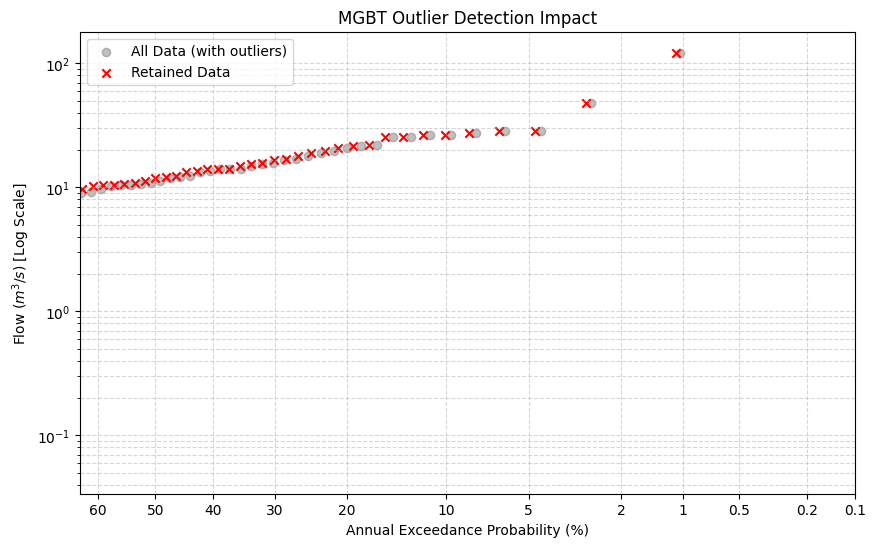

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate plotting positions
from flood_ffa.gev.plots import cunnane_plotting_positions

# All data
aep_all = cunnane_plotting_positions(flows_with_outliers.values)
ax.scatter(aep_all, flows_with_outliers.values, color="gray", alpha=0.5, label="All Data (with outliers)")

# Cleaned data
aep_clean = cunnane_plotting_positions(result_out.cleaned_flows.values)
ax.scatter(aep_clean, result_out.cleaned_flows.values, color="red", marker="x", label="Retained Data")

ax.set_xscale("prob")
ax.set_yscale("log")
ax.set_xlim([63, 0.1])
ax.set_xlabel("Annual Exceedance Probability (%)")
ax.set_ylabel("Flow ($m^3/s$) [Log Scale]")
ax.set_title("MGBT Outlier Detection Impact")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

## 5. Next Steps: Left-Censored Likelihood

In standard ARR practice, detected PILFs are handled using a **censored likelihood** during distribution fitting:

$$L(\theta) = \prod_{Q_i > \tau} f(Q_i;\,\theta) \;\times\; \prod_{Q_j \leq \tau} F(\tau;\,\theta)$$

where $\tau$ is the MGBT threshold, the first product is over uncensored observations (standard likelihood), and the second product is over censored observations — each contributing only the probability that the distribution assigns to values at or below $\tau$. This is the Expected Moments Algorithm (EMA) approach used in FLIKE and recommended by ARR 2019 for LP3 fitting with PILFs.

The `pyFloodExtremes` Bayesian modules currently use the **cleaned (uncensored) dataset** as input. For this particular gauge record, this is an acceptable simplification — `klow = 0` means no censoring is needed. An optional future enhancement would modify the PyMC models to incorporate the censored likelihood directly, enabling analysis of records that do contain PILFs. See `PLAN/session-digest.md` for the status of this planned extension.